<a href="https://colab.research.google.com/github/lamiya123-art/internship-persevex/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
dataset = pd.read_csv('data.csv')

In [4]:
print(dataset.head(5))

                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated                    str

In [5]:
obj = (dataset.dtypes == 'object')
object_cols = list(obj[obj].index)

print("Categorical variables:", len(object_cols))

Categorical variables: 5


In [6]:
int_ = (dataset.dtypes == 'int64')
num_cols = list(int_[int_].index)
print("Integer variables:", len(num_cols))

fl = (dataset.dtypes == 'float64')
fl_cols = list(fl[fl].index)
print("Float variables:", len(fl_cols))

Integer variables: 9
Float variables: 4


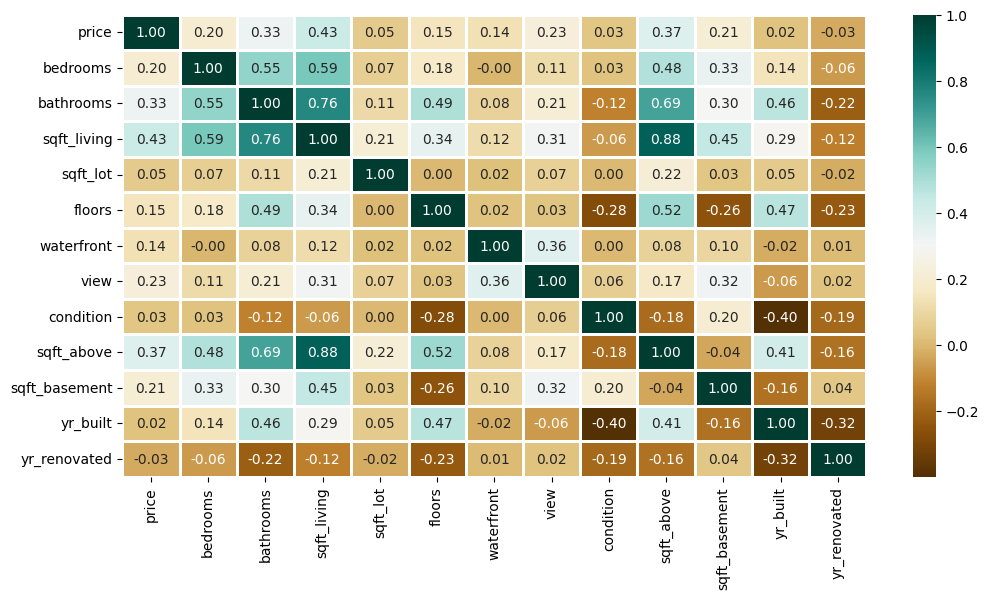

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_dataset = dataset.select_dtypes(include=['number'])

plt.figure(figsize=(12, 6))

sns.heatmap(
    numerical_dataset.corr(),
    cmap='BrBG',
    fmt='.2f',
    linewidths=2,
    annot=True
)

plt.show()

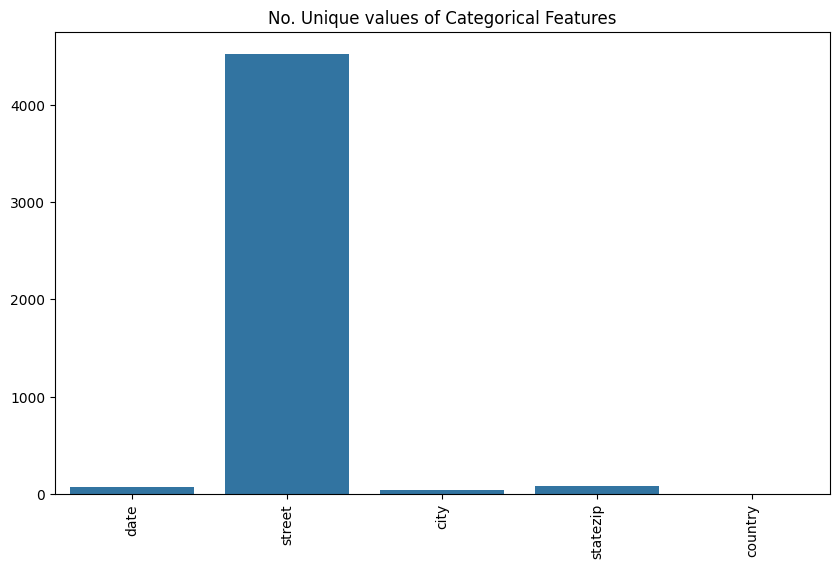

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

unique_values = []

for col in object_cols:
    unique_values.append(dataset[col].nunique())

plt.figure(figsize=(10, 6))
plt.title('No. Unique values of Categorical Features')
plt.xticks(rotation=90)

sns.barplot(x=object_cols, y=unique_values)

plt.show()

/tmp/ipykernel_18359/3051713069.py:20: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


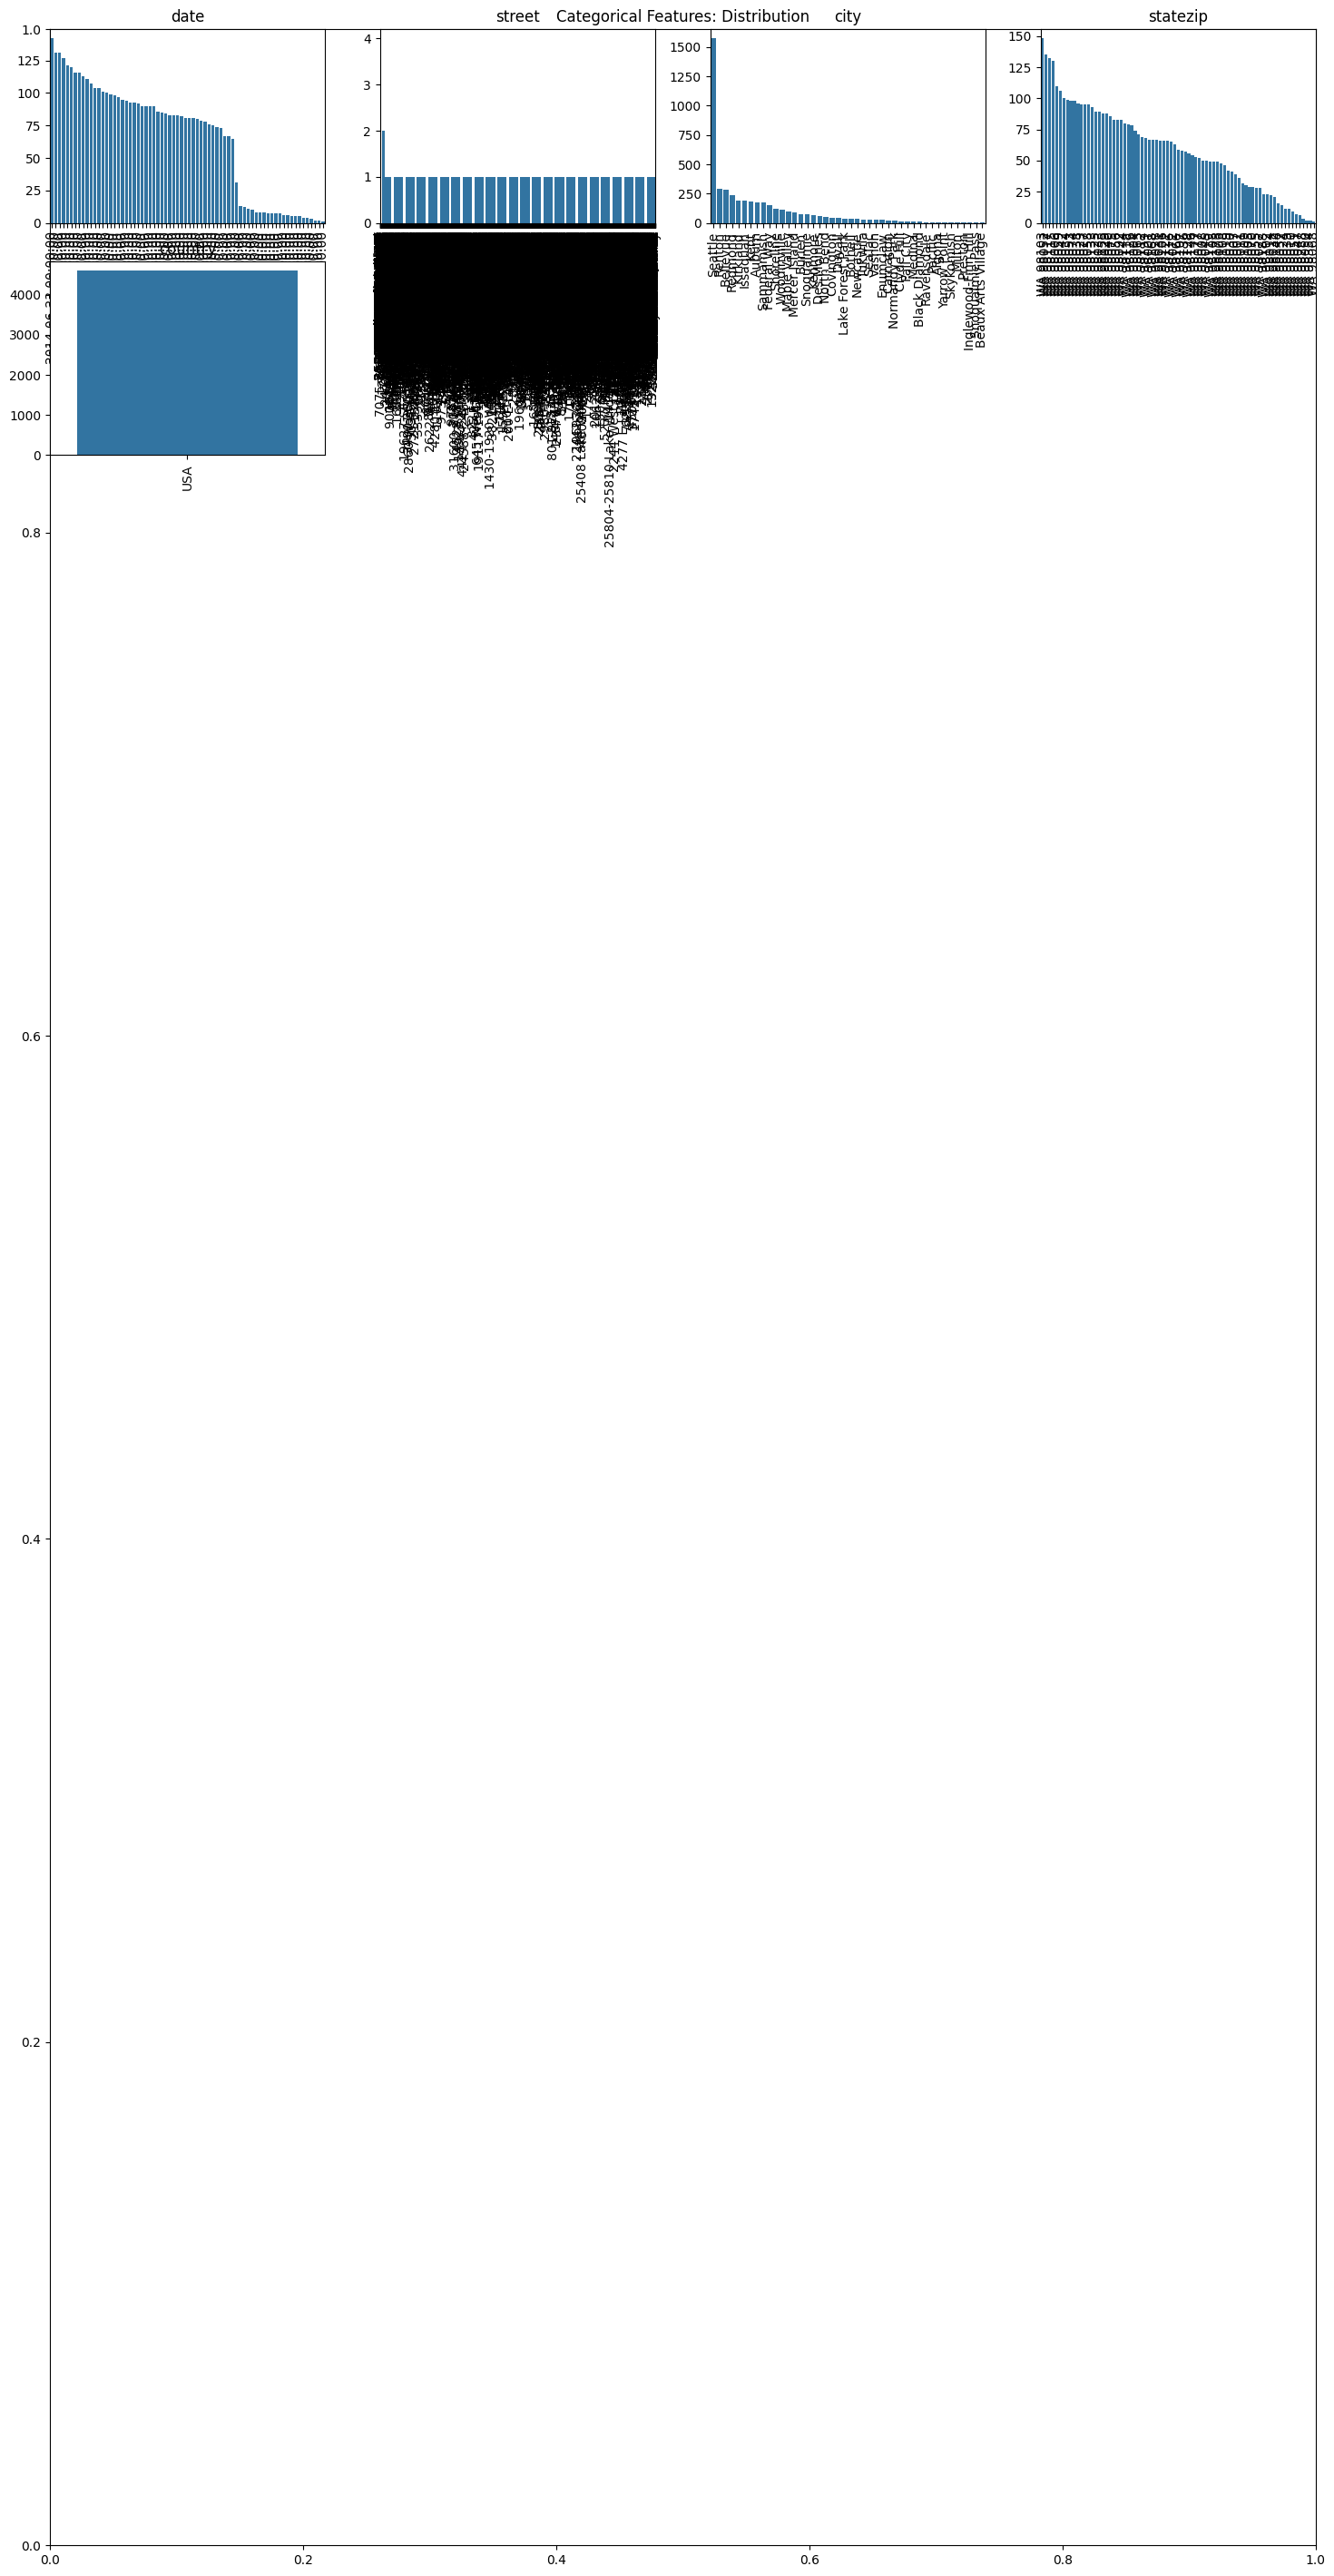

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 36))
plt.title('Categorical Features: Distribution')

index = 1

for col in object_cols:
    y = dataset[col].value_counts()

    plt.subplot(11, 4, index)
    sns.barplot(x=list(y.index), y=y.values)

    plt.xticks(rotation=90)
    plt.title(col)

    index += 1

plt.tight_layout()
plt.show()

In [11]:
# Fill missing values in 'price' with mean
dataset['price'] = dataset['price'].fillna(dataset['price'].mean())

# Drop remaining missing values
new_dataset = dataset.dropna()

# Check missing values
print(new_dataset.isnull().sum())

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64


In [12]:
from sklearn.preprocessing import OneHotEncoder

s = (new_dataset.dtypes == 'object')
object_cols = list(s[s].index)

print("Categorical variables:")
print(object_cols)

print("No. of categorical features:", len(object_cols))

Categorical variables:
['date', 'street', 'city', 'statezip', 'country']
No. of categorical features: 5


In [14]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

# One-hot encoding
OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

OH_cols = pd.DataFrame(
    OH_encoder.fit_transform(new_dataset[object_cols])
)

# Align index
OH_cols.index = new_dataset.index

# Add proper column names
OH_cols.columns = OH_encoder.get_feature_names_out(object_cols)

# Drop original categorical columns and concatenate encoded ones
df_final = new_dataset.drop(object_cols, axis=1)
df_final = pd.concat([df_final, OH_cols], axis=1)

# Split features and target
X = df_final.drop(['price'], axis=1)
Y = df_final['price']

# Train-test split
X_train, X_valid, Y_train, Y_valid = train_test_split(
    X, Y, train_size=0.8, test_size=0.2, random_state=0
)

# Model training
model = LinearRegression()
model.fit(X_train, Y_train)

# Predictions
preds = model.predict(X_valid)

# Evaluation
mae = mean_absolute_error(Y_valid, preds)
mape = mean_absolute_percentage_error(Y_valid, preds)

print("MAE:", mae)
print("MAPE:", mape)


MAE: 139549.0853551558
MAPE: 2.9842505896650285e+19
